# Statistics for Michel electron candidate (PDHD MC production New202508)

### Created by Shu, 202508---

#### To explore decay points distribution asymmetry along drift direction

<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />

## Initial candidates:

In [1]:
decayX_initial = []#Candidates after TPC cut---
decayY_initial = []
decayZ_initial = []

startX_initial = []#Candidates after TPC cut---
startY_initial = []
startZ_initial = []

MS_initial = []
MH_initial = []

with open('./statResult/decayX_initial.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        decayX_initial.append(float(currentPlace))
with open('./statResult/decayY_initial.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        decayY_initial.append(float(currentPlace))
with open('./statResult/decayZ_initial.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        decayZ_initial.append(float(currentPlace))

with open('./statResult/startX_initial.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        startX_initial.append(float(currentPlace))
with open('./statResult/startY_initial.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        startY_initial.append(float(currentPlace))
with open('./statResult/startZ_initial.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        startZ_initial.append(float(currentPlace))

with open('./statResult/michelScore_initial.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        MS_initial.append(float(currentPlace))
with open('./statResult/michelHits_initial.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        MH_initial.append(float(currentPlace))



print("Candidates ( MH > 0.01): decayX: ", len(decayX_initial))
print("Candidates ( MH > 0.01): decayY: ", len(decayY_initial))
print("Candidates ( MH > 0.01): decayZ: ", len(decayZ_initial))
print("Candidates ( MH > 0.01): startX: ", len(startX_initial))
print("Candidates ( MH > 0.01): startY: ", len(startY_initial))
print("Candidates ( MH > 0.01): startZ: ", len(startZ_initial))

print("Candidates ( MH > 0.01): MS: ", len(MS_initial))
print("Candidates ( MH > 0.01): MH: ", len(MH_initial))



Candidates ( MH > 0.01): decayX:  4824
Candidates ( MH > 0.01): decayY:  4824
Candidates ( MH > 0.01): decayZ:  4824
Candidates ( MH > 0.01): startX:  4824
Candidates ( MH > 0.01): startY:  4824
Candidates ( MH > 0.01): startZ:  4824
Candidates ( MH > 0.01): MS:  4824
Candidates ( MH > 0.01): MH:  4824


Decay points distribution: 

# of X < 0 :  2231 (46.248%)
# of X >= 0:  2593 (53.752%)


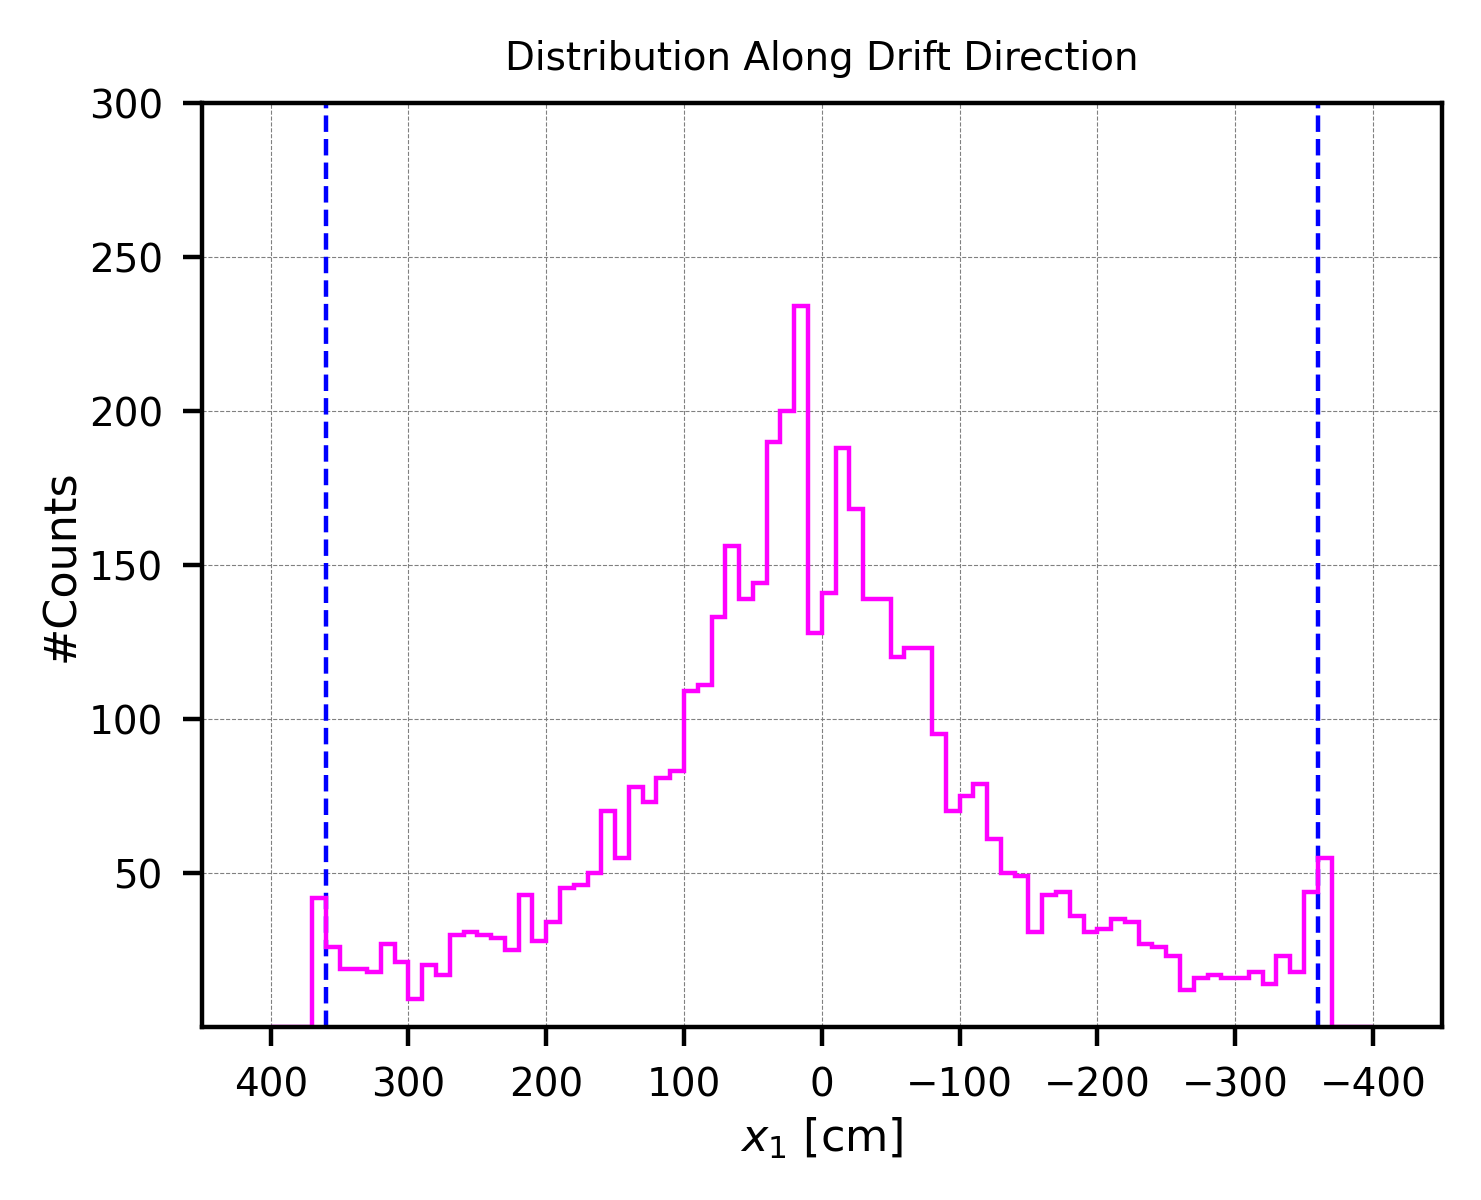

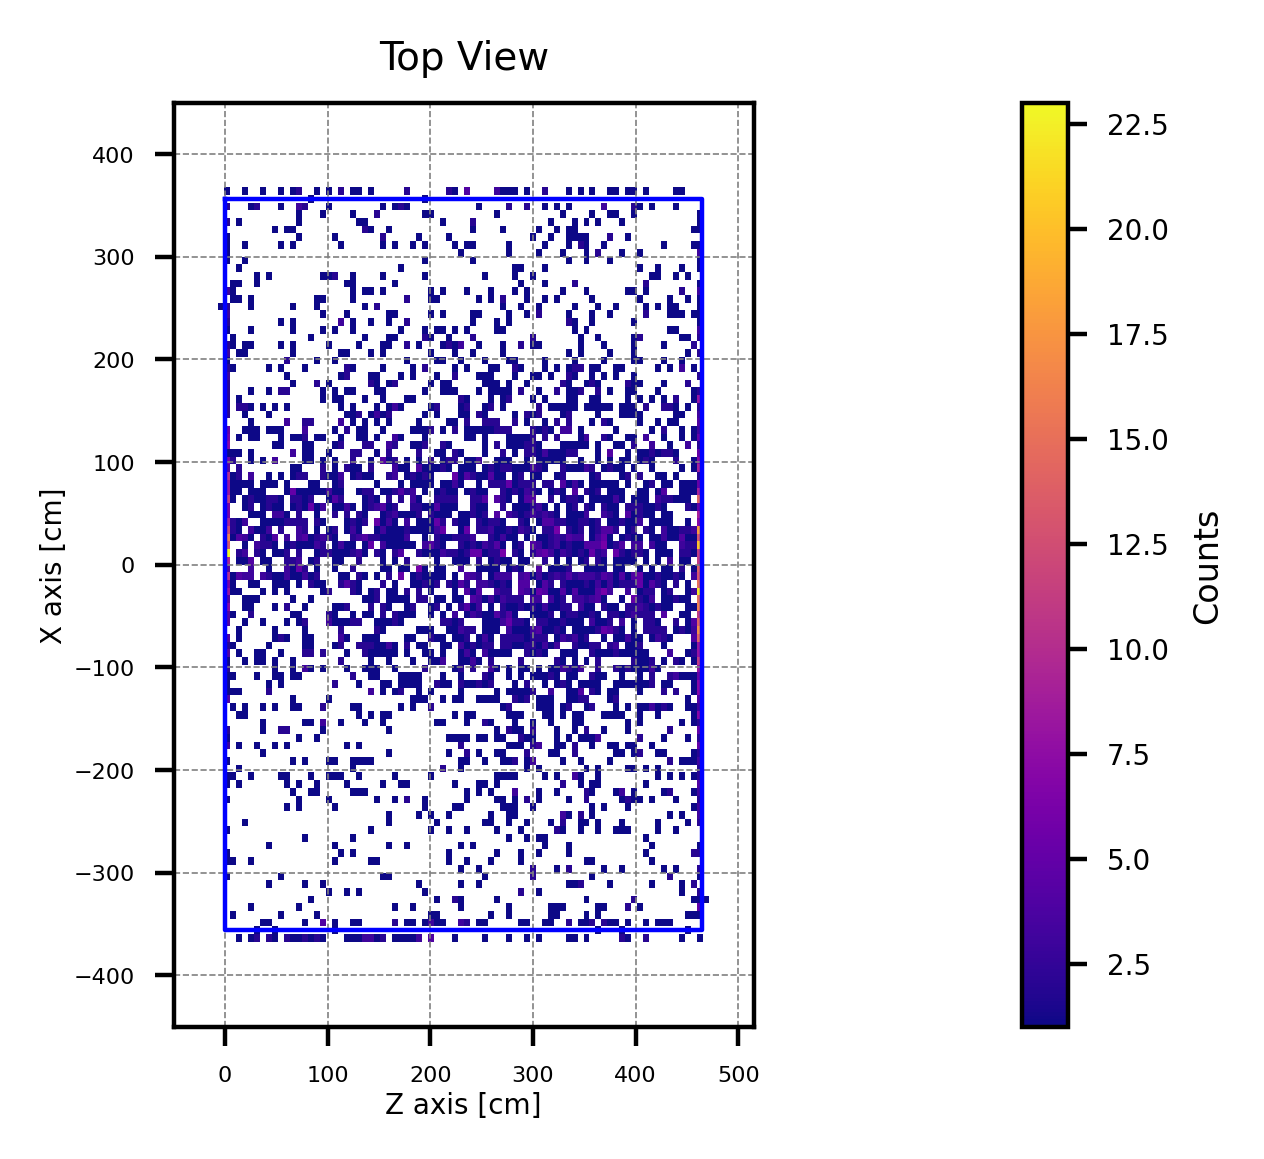

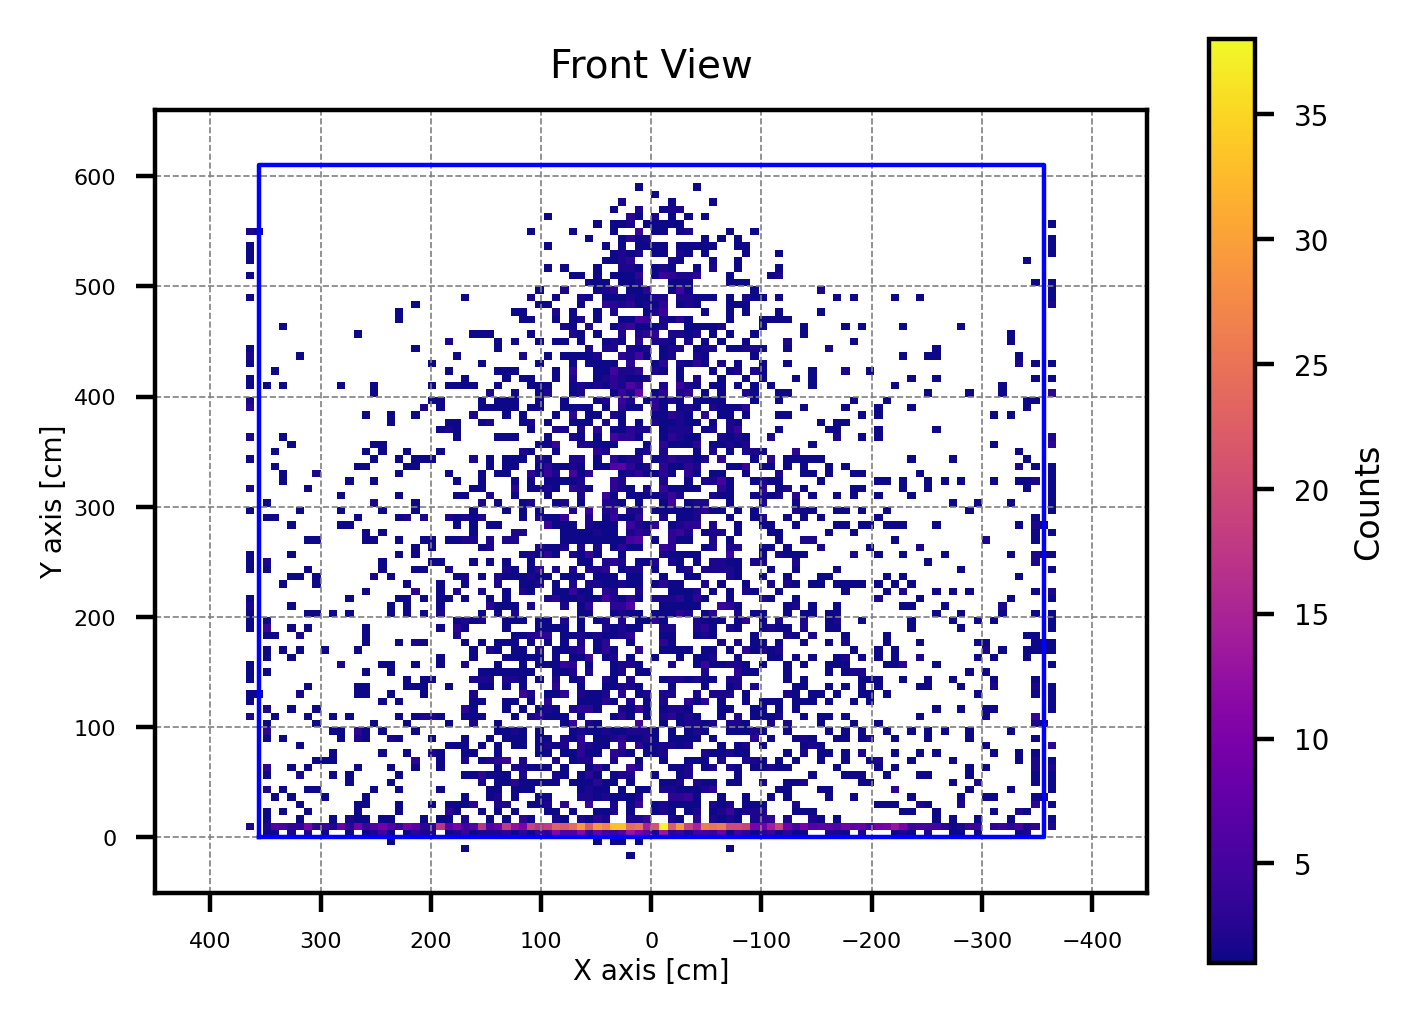

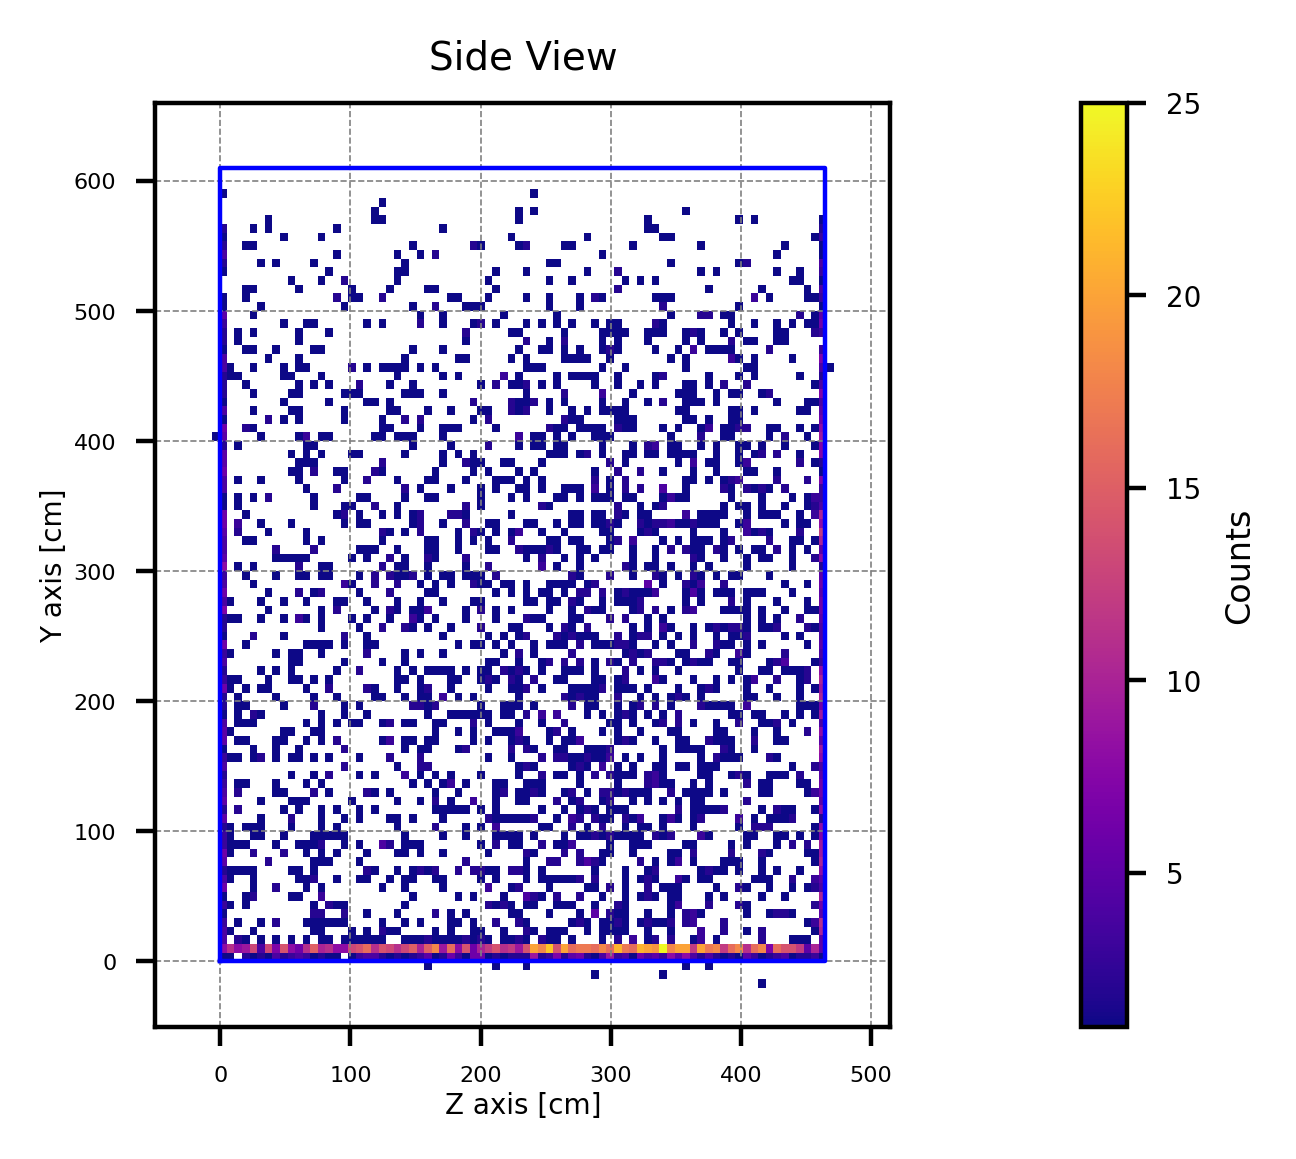

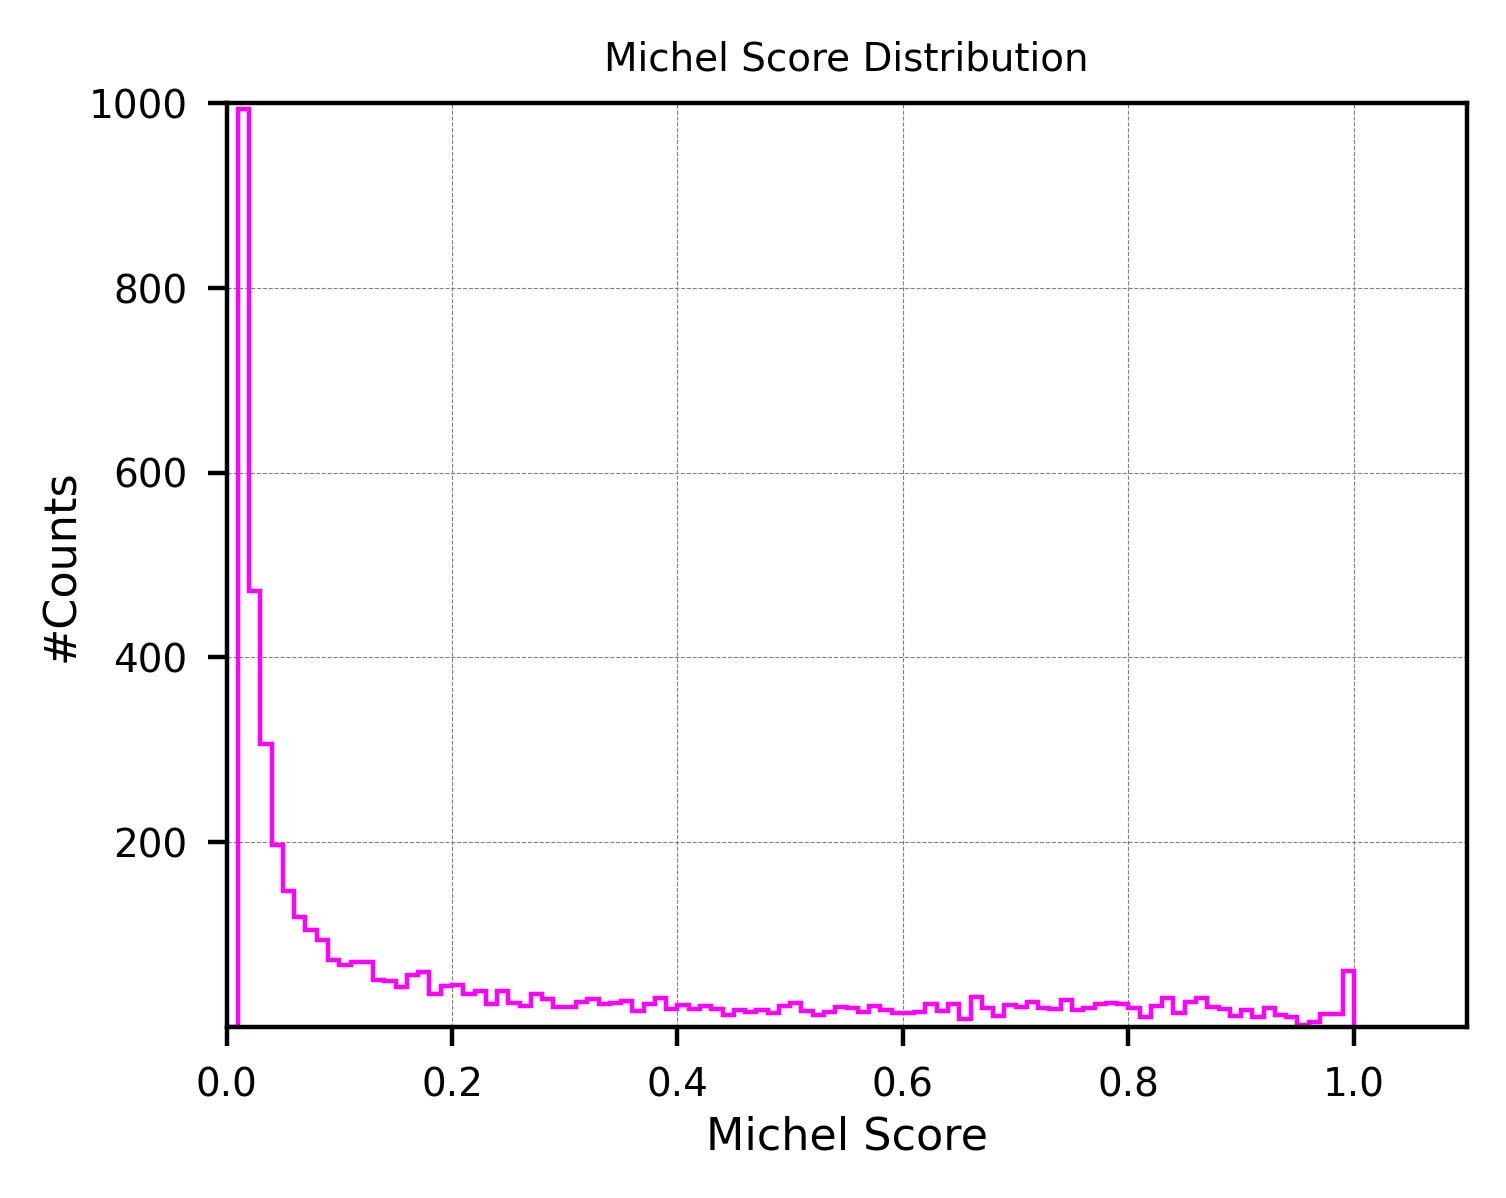

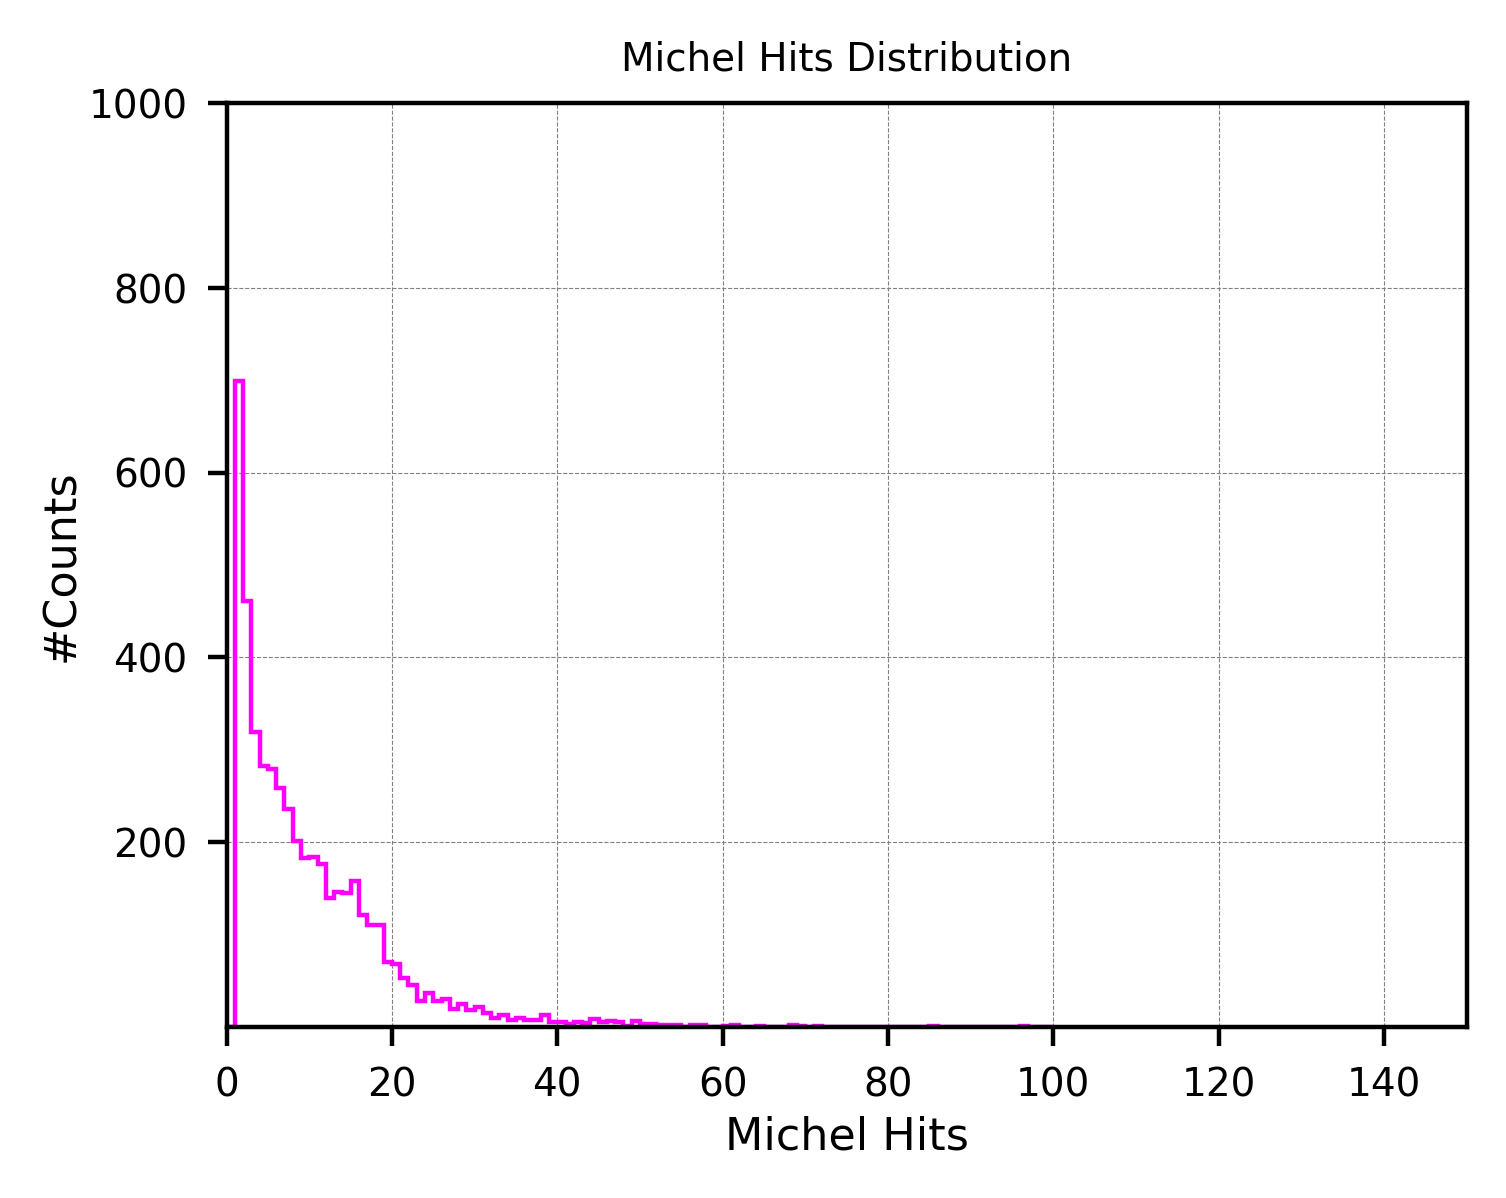




Starting points distribution: 


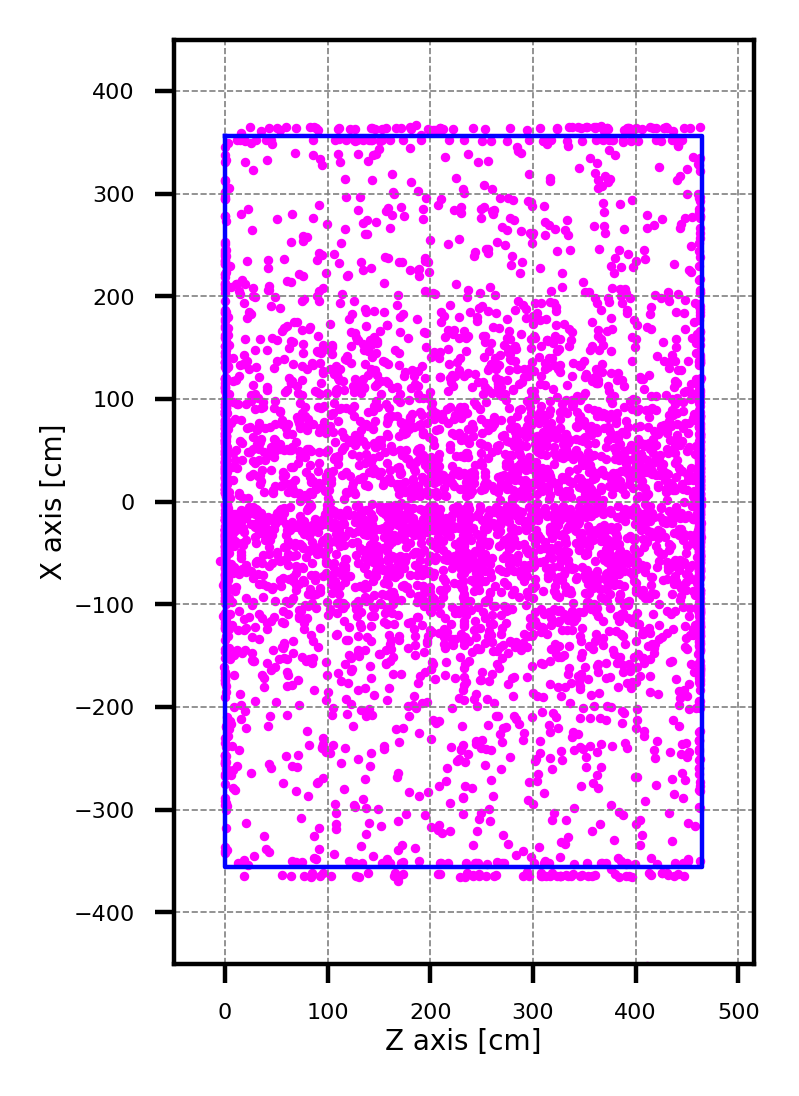

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

#Start drawing figures======================================    
#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465





#Decay points distribution:==========================================
print("Decay points distribution: ")

decayX_initial = np.array(decayX_initial)
neg_X = np.sum(decayX_initial < 0)
pos_X = np.sum(decayX_initial >= 0)
print("\n# of X < 0 : ", neg_X, "({:.3f}%)".format(neg_X/len(decayX_initial)*100))
print("# of X >= 0: ", pos_X, "({:.3f}%)".format(pos_X/len(decayX_initial)*100))



# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 300], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 300], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(decayX_initial, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)


plt.xlim(-450, 450)
plt.xlabel(r'$x_1$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0.1, 300)
#plt.yscale('log')
plt.title('Distribution Along Drift Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()  






#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(decayZ_initial, decayX_initial, bins=(120, 120), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()





#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(decayX_initial, decayY_initial, bins=(120, 120), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 




#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(decayZ_initial, decayY_initial, bins=(120, 120), range=[[zmin, zmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 







# Michel Score-------------------------------------------
plt.figure(figsize=(4,3),dpi=400)


#Define the range and bin width
bin_width = 0.01
range_min = 0
range_max = 1
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(MS_initial, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)


plt.xlim(0, 1.1)
plt.xlabel('Michel Score', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0.1, 1000)
#plt.yscale('log')
plt.title('Michel Score Distribution', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()  





# Michel Hit-------------------------------------------
plt.figure(figsize=(4,3),dpi=400)


#Define the range and bin width
bin_width = 1
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(MH_initial, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)


plt.xlim(0, 150)
plt.xlabel('Michel Hits', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0.1, 1000)
#plt.yscale('log')
plt.title('Michel Hits Distribution', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()  









#Starting points distribution:==========================================

print("\n\n\nStarting points distribution: ")

#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 465, 465, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux2, aux1, color="blue", linewidth=0.8, linestyle='-')

#Drawing of data points------
plt.scatter(startZ_initial, startX_initial, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()









<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />

## TPC cuts:

In [8]:
#After all cuts: Space, MS, MH---

TPC_X = []#After space and MS, MH cuts---
TPC_Y = []
TPC_Z = []
TPC_startX = []#After space and MS, MH cuts---
TPC_startY = []
TPC_startZ = []
TPC_MS = []
TPC_MH = []



#Selection------
for i in range(0, len(decayX_initial)):
    X = decayX_initial[i]
    Y = decayY_initial[i]
    Z = decayZ_initial[i]
    startX = startX_initial[i]
    startY = startY_initial[i]
    startZ = startZ_initial[i]    
    MS = MS_initial[i]
    MH = MH_initial[i]
  
    #Default region: 0<y<610, 0<z<465 (SPACE CUT)---
    if -356 < X < 356 and 30 < Y < 580 and 30 < Z < 435:
        if 0.4 < MS: #(Michel score cut)---
            if 5 < MH: #Michel hits cut---                
                TPC_X.append(X)
                TPC_Y.append(Y)
                TPC_Z.append(Z)
                TPC_startX.append(startX)
                TPC_startY.append(startY)
                TPC_startZ.append(startZ)
                TPC_MS.append(MS)
                TPC_MH.append(MH)
            

#Initial size of dataset:-----
print("Size of X (initial) : ", len(decayX_initial))


print("\nSize of X (TPC cuts) : ", len(TPC_X), "({:.3f}%)".format(len(TPC_X)/len(decayX_initial)*100))
print("Size of Y (TPC cuts) : ", len(TPC_Y))
print("Size of Z (TPC cuts) : ", len(TPC_Z))
print("Size of startX (TPC cuts) : ", len(TPC_startX))
print("Size of startY (TPC cuts) : ", len(TPC_startY))
print("Size of startZ (TPC cuts) : ", len(TPC_startZ))
print("Size of MS (TPC cuts): ", len(TPC_MS))
print("Size of MH (TPC cuts): ", len(TPC_MH))

Size of X (initial) :  4824

Size of X (TPC cuts) :  678 (14.055%)
Size of Y (TPC cuts) :  678
Size of Z (TPC cuts) :  678
Size of startX (TPC cuts) :  678
Size of startY (TPC cuts) :  678
Size of startZ (TPC cuts) :  678
Size of MS (TPC cuts):  678
Size of MH (TPC cuts):  678


Decay points distribution: 

# of X < 0 :  242 (35.693%)
# of X >= 0:  436 (64.307%)


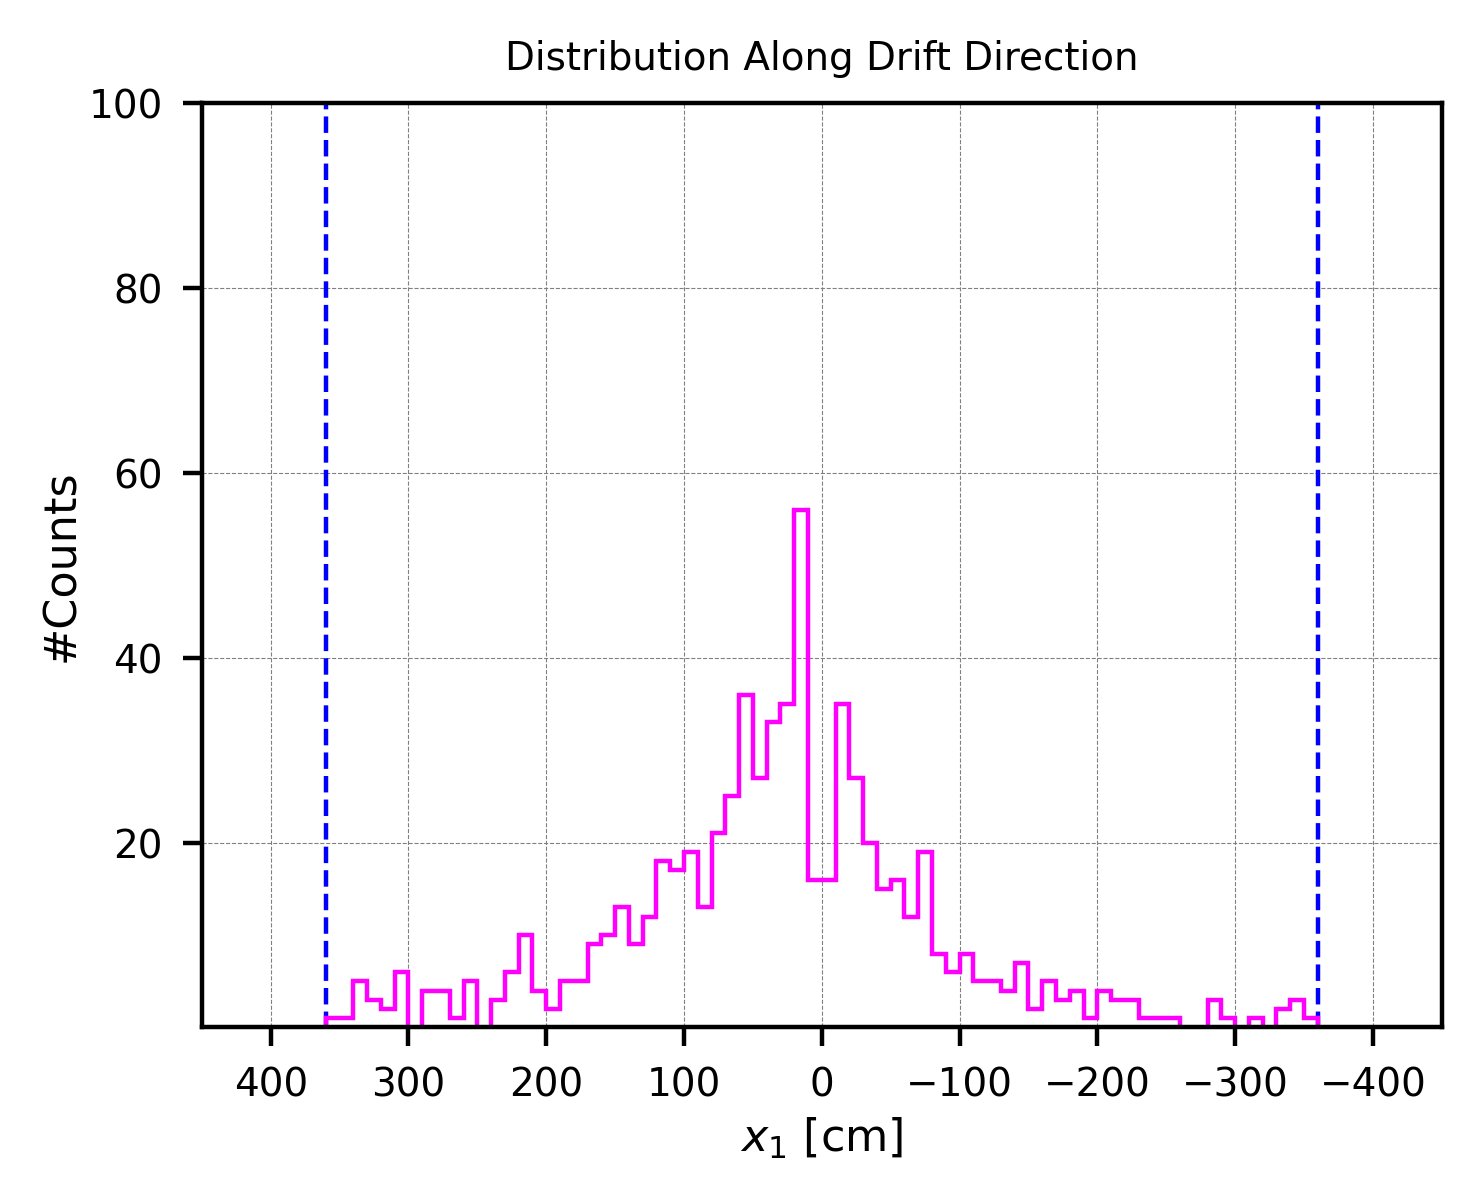

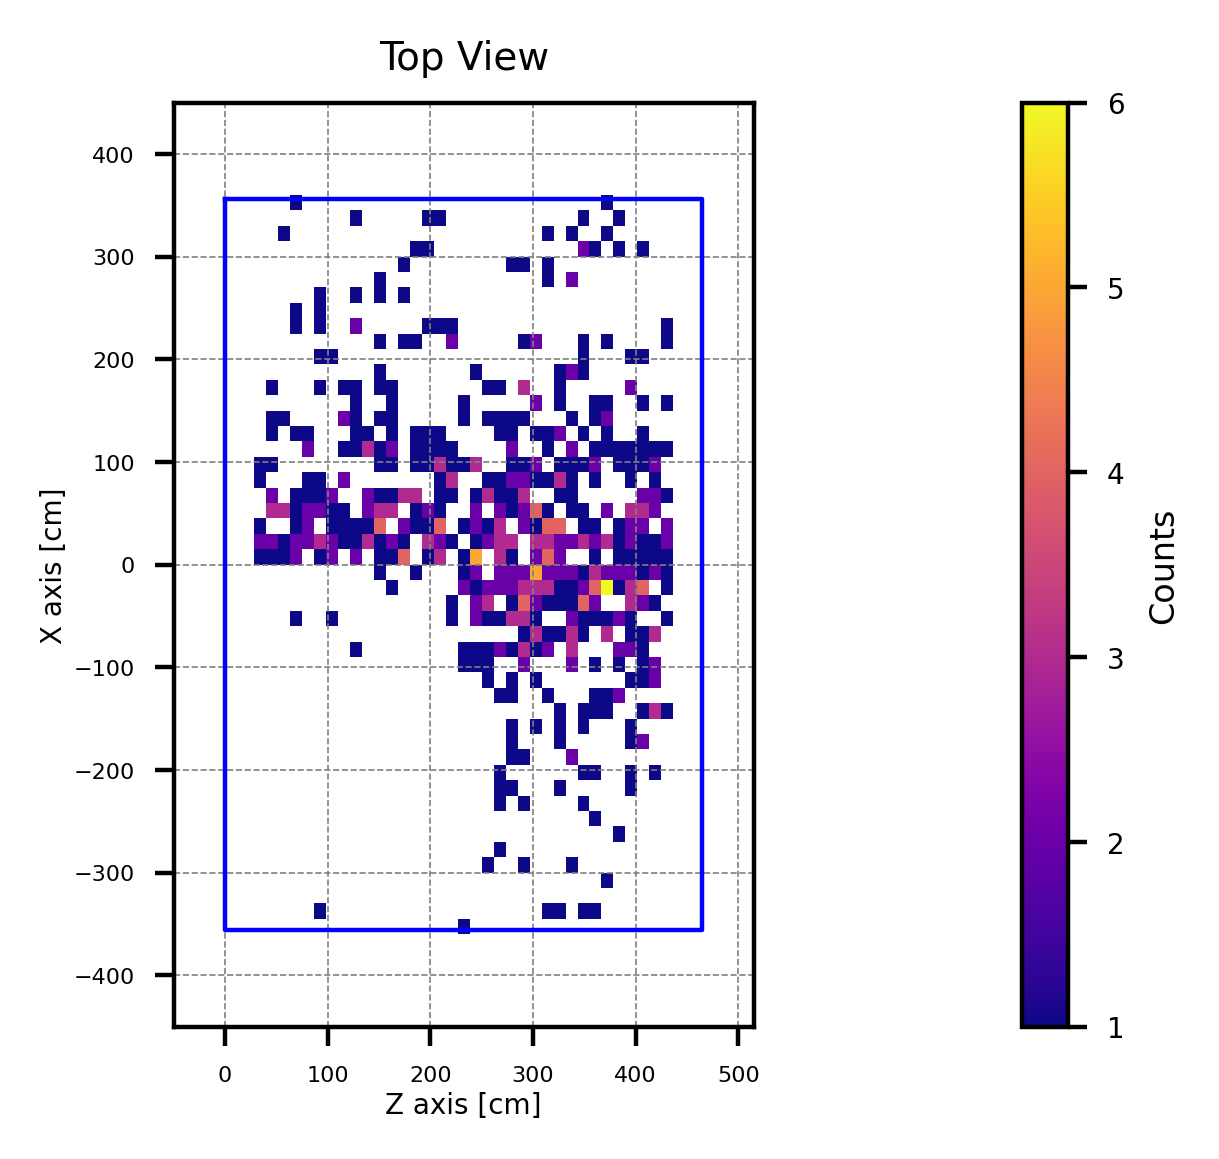

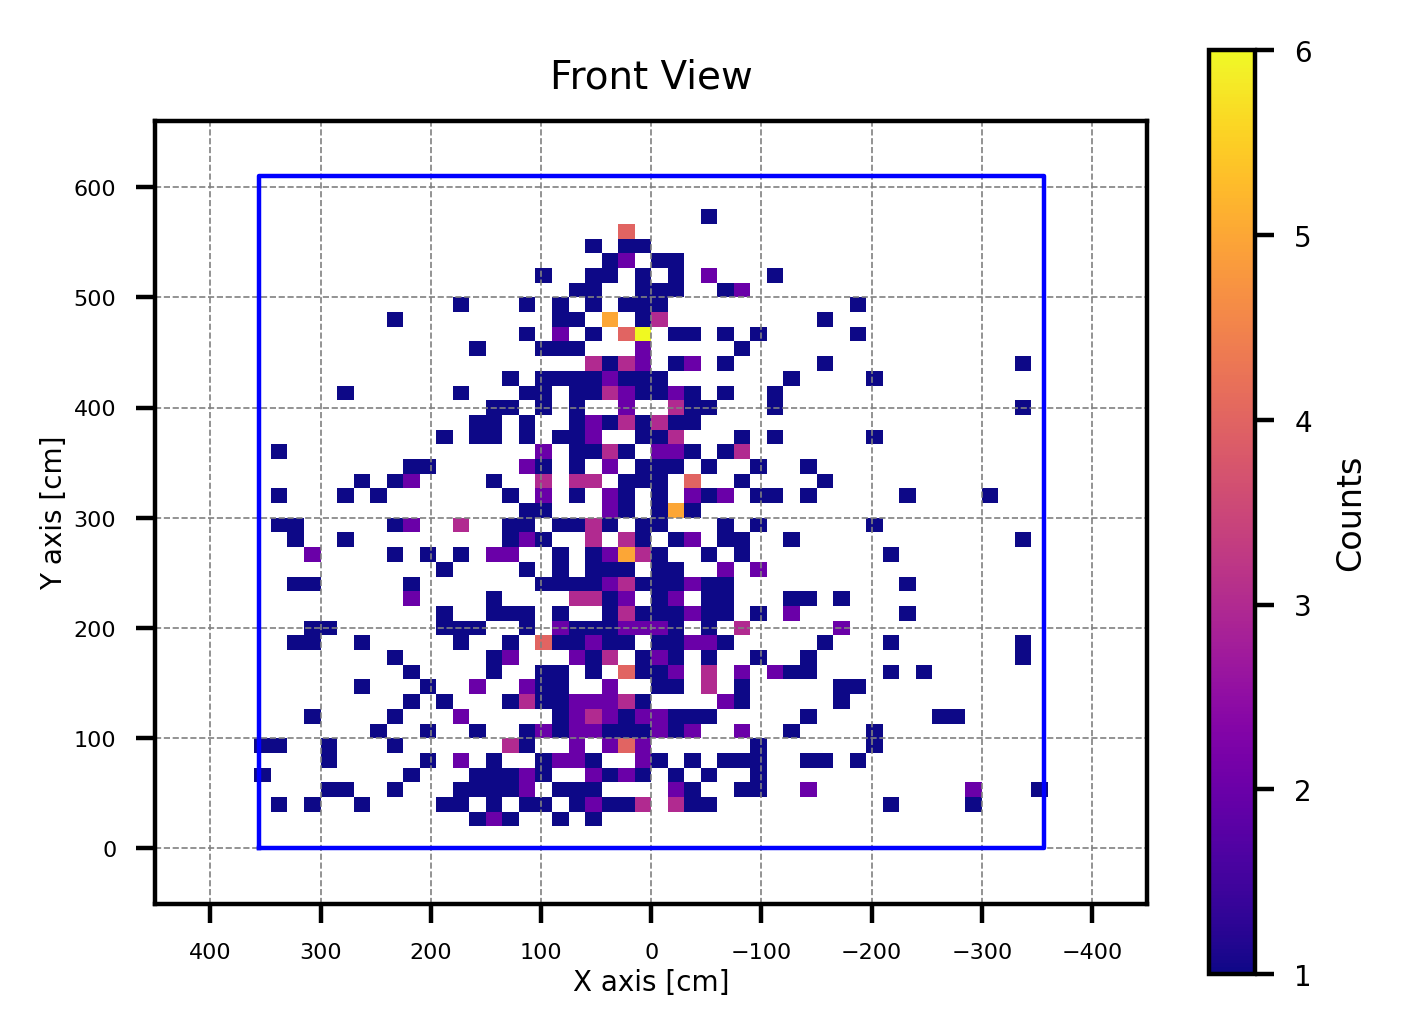

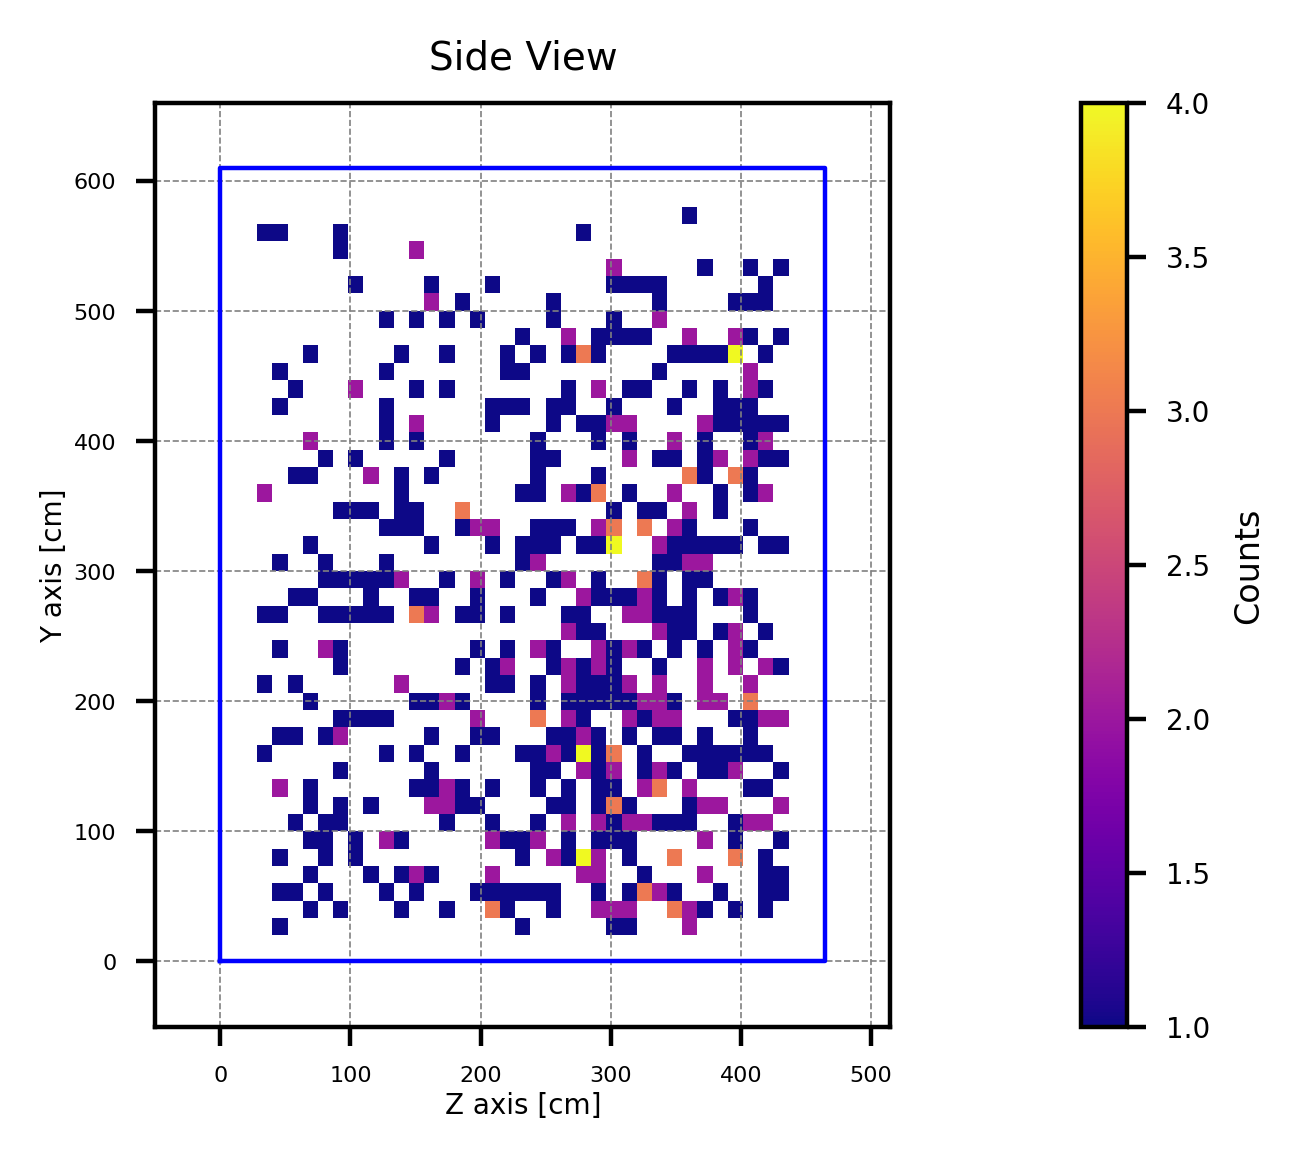

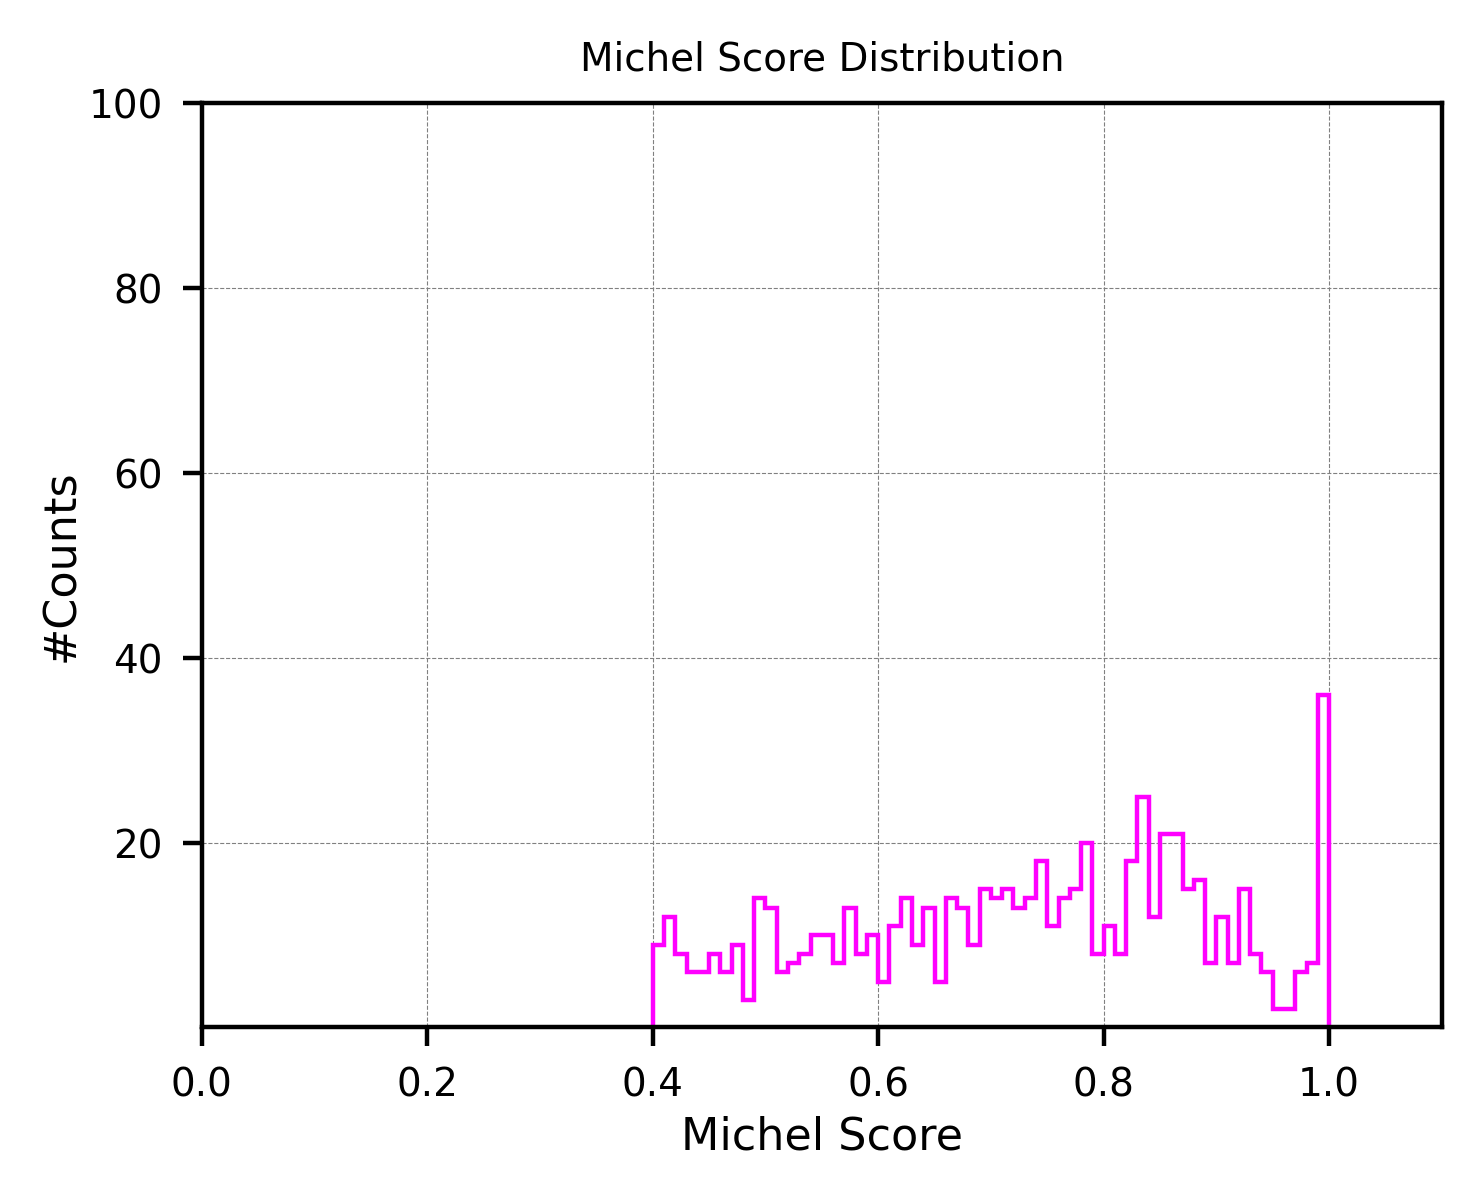

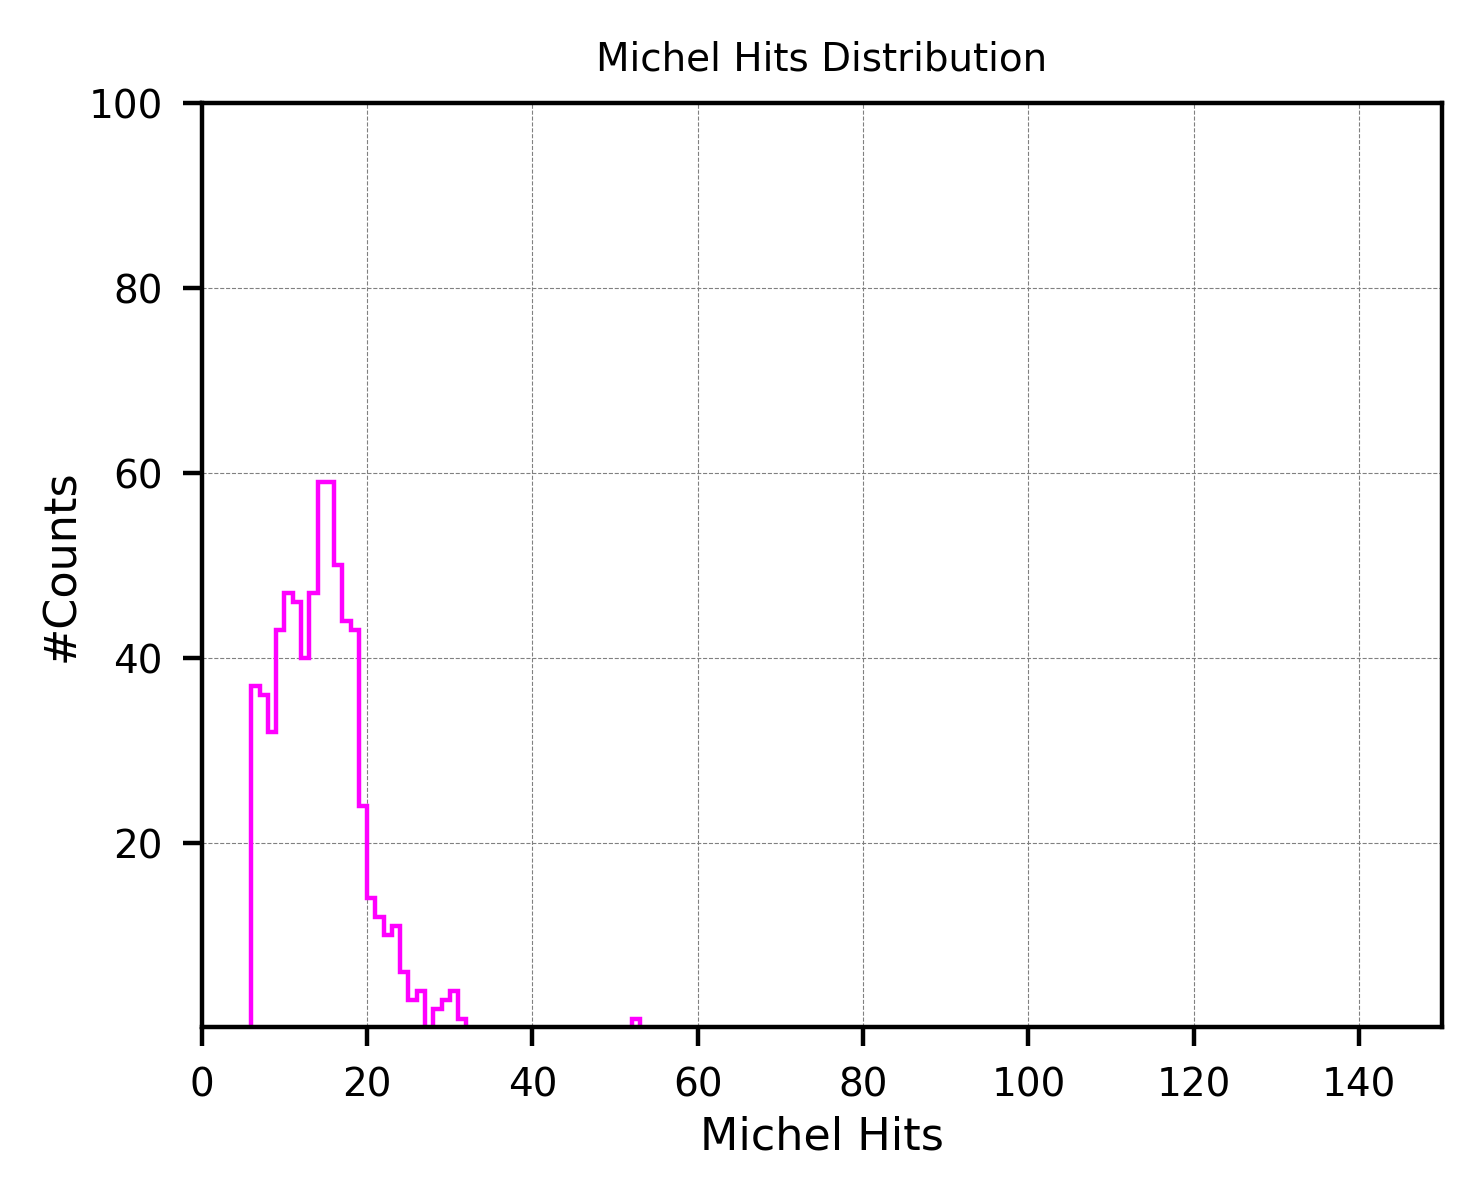




Starting points distribution: 


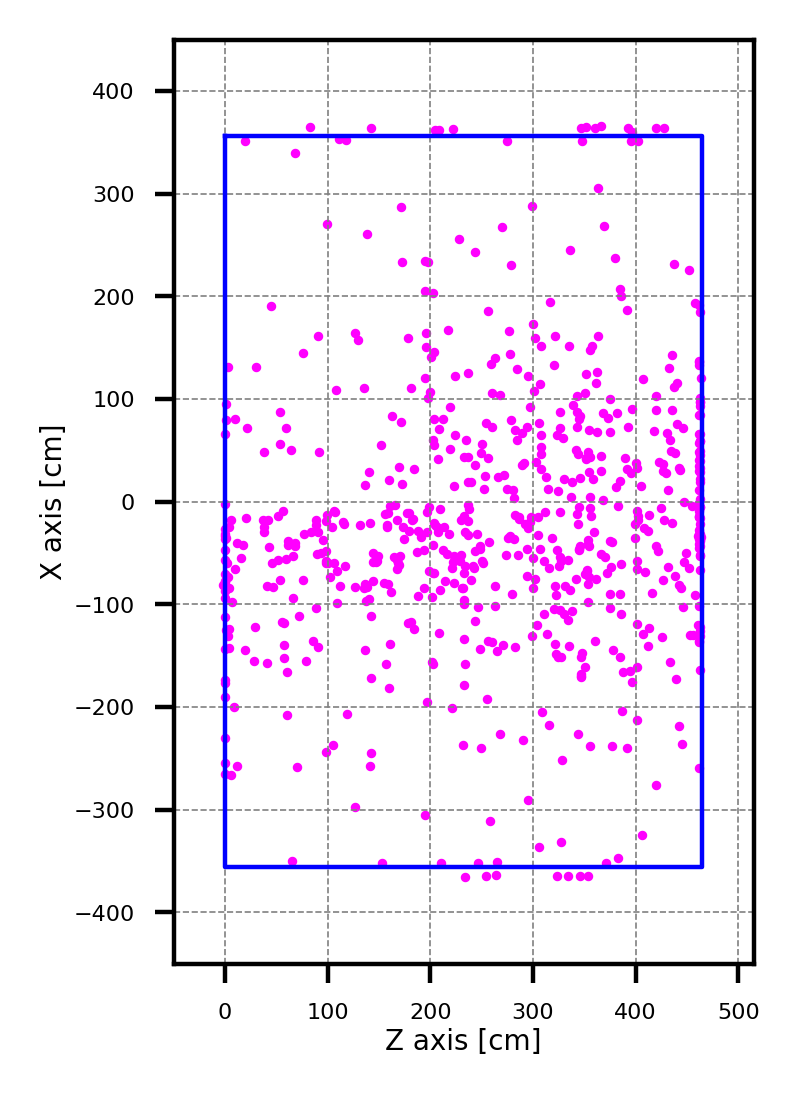

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

#Start drawing figures======================================    
#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465





#Decay points distribution:==========================================
print("Decay points distribution: ")

TPC_X = np.array(TPC_X)
neg_X = np.sum(TPC_X < 0)
pos_X = np.sum(TPC_X >= 0)
print("\n# of X < 0 : ", neg_X, "({:.3f}%)".format(neg_X/len(TPC_X)*100))
print("# of X >= 0: ", pos_X, "({:.3f}%)".format(pos_X/len(TPC_X)*100))




# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 100], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 100], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(TPC_X, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)


plt.xlim(-450, 450)
plt.xlabel(r'$x_1$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0.1, 100)
#plt.yscale('log')
plt.title('Distribution Along Drift Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()  






#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(TPC_Z, TPC_X, bins=(60, 60), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()





#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(TPC_X, TPC_Y, bins=(60, 60), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 




#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(TPC_Z, TPC_Y, bins=(60, 60), range=[[zmin, zmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 







# Michel Score-------------------------------------------
plt.figure(figsize=(4,3),dpi=400)


#Define the range and bin width
bin_width = 0.01
range_min = 0
range_max = 1
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(TPC_MS, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)


plt.xlim(0, 1.1)
plt.xlabel('Michel Score', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0.1, 100)
#plt.yscale('log')
plt.title('Michel Score Distribution', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()  





# Michel Hit-------------------------------------------
plt.figure(figsize=(4,3),dpi=400)


#Define the range and bin width
bin_width = 1
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(TPC_MH, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)


plt.xlim(0, 150)
plt.xlabel('Michel Hits', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.ylim(0.1, 100)
#plt.yscale('log')
plt.title('Michel Hits Distribution', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()  









#Starting points distribution:==========================================

print("\n\n\nStarting points distribution: ")

#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 465, 465, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux2, aux1, color="blue", linewidth=0.8, linestyle='-')

#Drawing of data points------
plt.scatter(TPC_startZ, TPC_startX, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()

<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />

## Candidate after TPC cuts:

<br />
<br />

### Wvf coincidence:

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D


# Specify the file name
#read data---
merged = []

# Open the text file and process each line
with open('./statResult/print_wvfCoin_count.txt', "r") as file:
    for line in file:
        line = line.strip()  # Remove any leading/trailing whitespace
        if not line:  # Skip empty lines
            continue
        # Each line is expected to be in the format: <filepath>: <number>
        parts = line.split(":")
        if len(parts) >= 2:
            try:
                # Convert the part after the colon to an integer and add to the list
                number = int(parts[1].strip())
                merged.append(number)
            except ValueError:
                print(f"(muon time) Could not convert {parts[1].strip()} to an integer.")





print("Intial event candidates:  93")
print("Length of merged       : ", len(merged))

#For 5340 candidates:
#noMerge: /Users/shuaixiangzhang/Work/current/FNAL_Work2024/michel_e/t0_tagging/pdhd_DATA_v2/analyze_pdhd_DATA_v2/ \
#         analyze/v2_main/data_src_decon_FullRun/print_wvfCoin.txt; search for "No valid histograms found"
#merged: /Users/shuaixiangzhang/Work/current/FNAL_Work2024/michel_e/t0_tagging/pdhd_DATA_v2/analyze_pdhd_DATA_v2/ \
#        analyze/v2_main/data_src_decon_FullRun/print_wvfCoin_merged.txt; search for "No valid histograms found"

merged.extend([0] * 9)

print("Length of merged: (+ 9 0s): ", len(merged))

Intial event candidates:  93
Length of merged       :  121
Length of merged: (+ 9 0s):  130


Merged  (#wvf >= 5):  69 (53.08%)


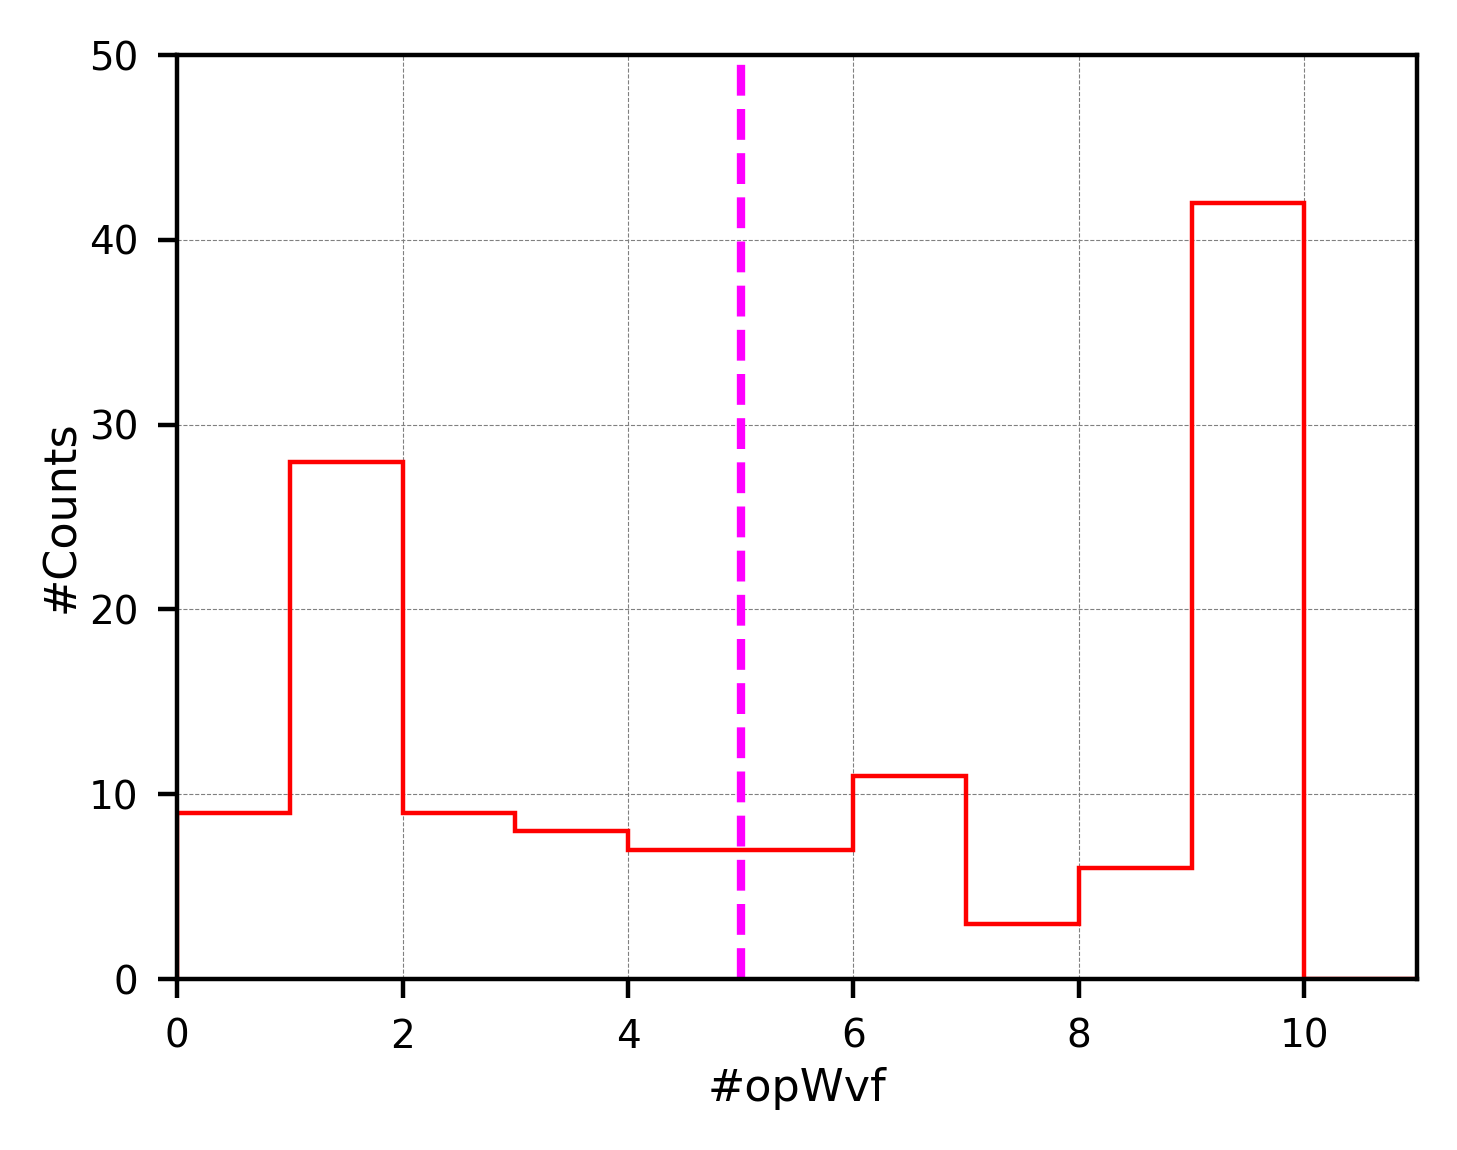

In [8]:

#Simple statistics------
num_merged_ge5 = sum(1 for x in merged if x >= 5)

#Event candidates (after space, MS & MH cuts):
print("Merged  (#wvf >= 5): ", num_merged_ge5, "({:.2f}%)".format(num_merged_ge5/len(merged)*100))



# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 1
range_min = 0
range_max = 11
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.plot([5, 5], [0, 1200], color="magenta", linewidth=1.5, linestyle='--')

plt.hist(merged, bins=bins, range=(range_min, range_max), edgecolor='red', 
         histtype='step', linewidth=0.8, label='Merged Result')

#plt.legend(loc='upper center', bbox_to_anchor=(0.75, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.xlim(0, 11)
plt.ylim(0, 50)
plt.xlabel('#opWvf', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 1000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show() 